In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error

from patsy import dmatrix, build_design_matrices

from statsmodels.graphics.gofplots import ProbPlot
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 폰트 설정
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"  
font_prop = fm.FontProperties(fname=font_path)
mpl.rcParams['font.family'] = font_prop.get_name()
mpl.rcParams['axes.unicode_minus'] = False

In [4]:
df = pd.read_excel('./datasets/swatch.xlsx')
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con)
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


In [5]:
# info
print('shape:', df.shape)
print()
print(df.info())

shape: (9, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sample               9 non-null      object 
 1   평량(g/m2)             9 non-null      float64
 2   BET(m2/g)            9 non-null      int64  
 3   SWATCH(GD) 24h(Con)  9 non-null      int64  
 4   SWATCH(HD) 24h(Con)  9 non-null      int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 492.0+ bytes
None


In [6]:
# Descriptive Statistics
desc_stats = df.drop(columns='Sample').copy()
desc_stats = df.describe().T
desc_stats['CV(%)'] = (desc_stats['std'] / desc_stats['mean'] * 100)

print('기술 통계')
display(desc_stats.round(2))

print()
print('미군 방호성능 기준 합/불 여부')
GD_base = 357
HD_base = 671

df['GD_PASS'] = df['SWATCH(GD) 24h(Con)'] <= GD_base
df['HD_PASS'] = df['SWATCH(HD) 24h(Con)'] <= HD_base
df['All_PASS'] = (df['SWATCH(GD) 24h(Con)'] <= GD_base) & (df['SWATCH(HD) 24h(Con)'] <= HD_base)

summary = df.copy()
summary['GD_PASS'] = summary['GD_PASS'].map({True: '합격', False: '불합격'})
summary['HD_PASS'] = summary['HD_PASS'].map({True: '합격', False: '불합격'})
summary['All_PASS'] = summary['All_PASS'].map({True: '합격', False: '불합격'})
display(summary)

print('HD 합격 샘플:', summary.loc[summary['GD_PASS'] == '합격', 'Sample'].tolist())
print('GD 합격 샘플:', summary.loc[summary['HD_PASS'] == '합격', 'Sample'].tolist())
print('모두 합격 샘플:', summary.loc[summary['All_PASS'] == '합격', 'Sample'].tolist())

기술 통계


,count,mean,std,min,25%,50%,75%,max,CV(%)
평량(g/m2),9.0,120.60,18.40,99.3,105.2,119.7,130.0,154.49,15.26
BET(m2/g),9.0,1309.11,358.18,1016.0,1139.0,1150.0,1300.0,2197.00,27.36
SWATCH(GD) 24h(Con),9.0,414.44,385.85,20.0,50.0,380.0,470.0,1150.00,93.10
SWATCH(HD) 24h(Con),9.0,293.33,302.81,5.0,10.0,220.0,550.0,850.00,103.23



미군 방호성능 기준 합/불 여부


,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con),GD_PASS,HD_PASS,All_PASS
0,ACF25-01,105.20,1150,320,280,합격,합격,합격
1,ACF25-02,99.30,1450,470,220,불합격,합격,불합격
2,ACF25-03,119.70,1150,1150,550,불합격,합격,불합격
3,ACF25-04,110.40,1300,850,850,불합격,불합격,불합격
4,ACF25-05,103.44,1016,470,580,불합격,합격,불합격
5,ACF25-06,122.83,1080,20,140,합격,합격,합격
6,ACF25-07,154.49,1139,380,10,불합격,합격,불합격
7,ACF25-08,140.00,1300,20,5,합격,합격,합격
8,ACF25-09,130.00,2197,50,5,합격,합격,합격


HD 합격 샘플: ['ACF25-01', 'ACF25-06', 'ACF25-08', 'ACF25-09']
GD 합격 샘플: ['ACF25-01', 'ACF25-02', 'ACF25-03', 'ACF25-05', 'ACF25-06', 'ACF25-07', 'ACF25-08', 'ACF25-09']
모두 합격 샘플: ['ACF25-01', 'ACF25-06', 'ACF25-08', 'ACF25-09']


# 변수 분포 시각화

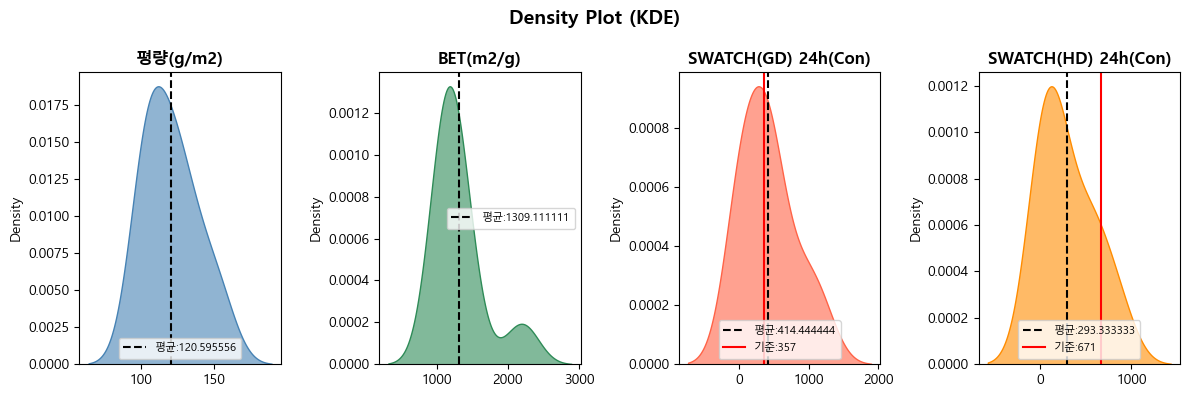

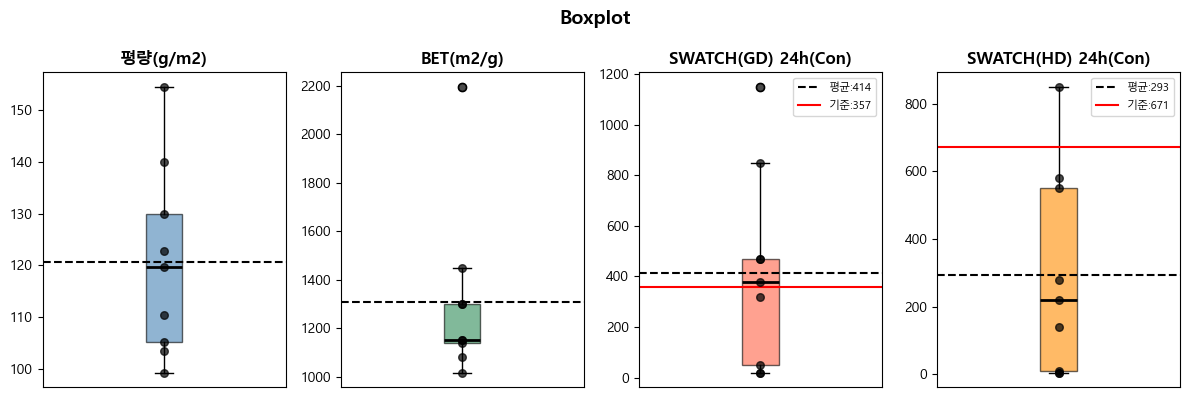

In [7]:
cols = df.columns[1:5].tolist()
limits = [None, None, GD_base, HD_base]
colors = ['steelblue', 'seagreen', 'tomato', 'darkorange']

# Density Plot
figs, axes = plt.subplots(1,4, figsize=(12,4))
for i, (col, lim, color) in enumerate(zip(cols, limits, colors)):
    ax_density = axes[i]
    
    temp = pd.to_numeric(df[col]).dropna()

    sns.kdeplot(temp, ax=ax_density, fill=True, color=color, alpha=0.6)

    ax_density.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'평균:{df[col].mean():0f}')

    if lim:
        ax_density.axvline(lim, color='red', linestyle='-', linewidth=1.5, label=f'기준:{lim}')
    ax_density.set_title(col, fontsize=12, fontweight='bold')
    ax_density.set_xlabel('')
    ax_density.legend(fontsize=8)

plt.suptitle('Density Plot (KDE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplot
figs, axes = plt.subplots(1,4, figsize=(12,4))
for i, (col, lim, color) in enumerate(zip(cols, limits, colors)):
    ax_box = axes[i]
    
    ax_box.boxplot(df[col], patch_artist=True,
                        boxprops=dict(facecolor=color, alpha=0.6),
                        medianprops=dict(color='black', linewidth=2))
    ax_box.axhline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'평균:{df[col].mean():.0f}')

    if lim:
        ax_box.axhline(lim, color='red', linestyle='-', linewidth=1.5, label=f'기준:{lim}')
        ax_box.legend(fontsize=8)

    ax_box.scatter([1]*len(df), df[col], color='black', zorder=5, s=30, alpha=0.7)
    ax_box.set_title(col, fontsize=12, fontweight='bold')
    ax_box.set_xticks([])

plt.suptitle('Boxplot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# (샘플별) 미군 방호성능 24시간 기준 합/불 여부

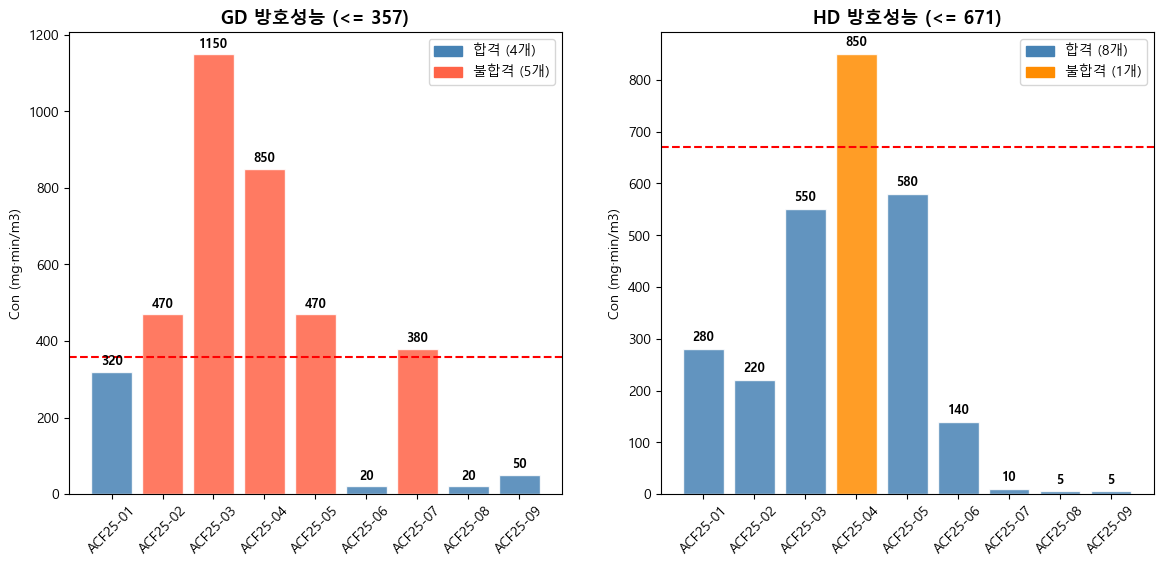

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
for ax, (y_col, lim, color, title) in zip(axes, [
    ('SWATCH(GD) 24h(Con)', GD_base, 'tomato',    'GD 방호성능 (<= 357)'),
    ('SWATCH(HD) 24h(Con)', HD_base, 'darkorange','HD 방호성능 (<= 671)')]):

    pass_mask = df[y_col] <= lim
    bar_colors = [color if not p else 'steelblue' for p in pass_mask]

    bars = ax.bar(df['Sample'], df[y_col], color=bar_colors, edgecolor='white', alpha=0.85)
    ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, label=f'기준:{lim}')

    for bar, val in zip(bars, df[y_col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+10,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    # ax.set_xlabel('Sample')
    ax.set_ylabel('Con (mg·min/m3)')
    ax.tick_params(axis='x', rotation=45)

    # 범례
    pass_patch = mpatches.Patch(color='steelblue', label=f'합격 ({pass_mask.sum()}개)')
    fail_patch = mpatches.Patch(color=color, label=f'불합격 ({(~pass_mask).sum()}개)')
    ax.legend(handles=[pass_patch, fail_patch])

# (변수별) 미군 방호성능 24시간 기준 합/불 여부

In [9]:
pairs = [
    ('평량(g/m2)', 'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'steelblue', GD_base),
    ('BET(m2/g)',  'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'seagreen',  GD_base),
    ('평량(g/m2)', 'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'darkorange', HD_base),
    ('BET(m2/g)',  'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'mediumpurple', HD_base),
]

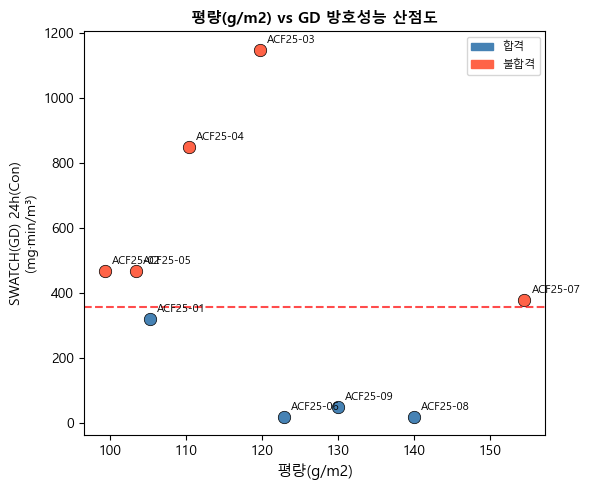

In [10]:
fig, ax = plt.subplots(figsize=(6,5))

x_col, y_col, y_label, color, lim = pairs[0]

x = df[x_col]
y = df[y_col]

slope, intercept, r, p, se = stats.linregress(x, y)

for _, row in df.iterrows():
    c = 'steelblue' if row[y_col] <= lim else 'tomato'
    ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
    ax.annotate(row['Sample'], (row[x_col], row[y_col]),
        textcoords='offset points', xytext=(5, 5), fontsize=8)

# 기준선
ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

# 레이블
ax.set_xlabel(x_col, fontsize=11)
ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
ax.set_title(f'{x_col} vs {y_label} 산점도', fontsize=11, fontweight='bold')

# 범례
pass_p = mpatches.Patch(color='steelblue', label='합격')
fail_p = mpatches.Patch(color='tomato', label='불합격')
ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

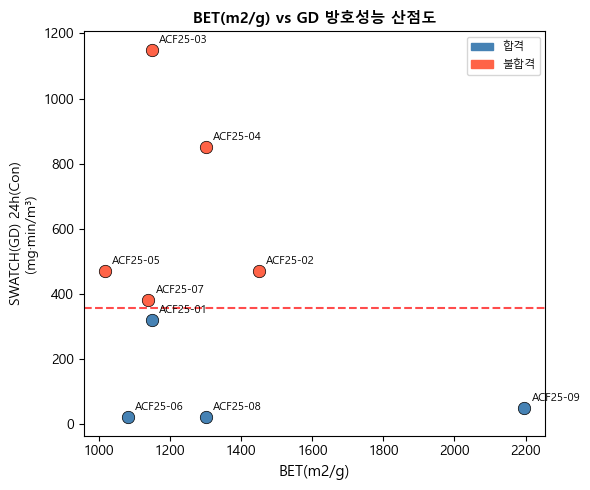

In [11]:
fig, ax = plt.subplots(figsize=(6,5))

x_col, y_col, y_label, color, lim = pairs[1]

x = df[x_col]
y = df[y_col]

slope, intercept, r, p, se = stats.linregress(x, y)

for _, row in df.iterrows():
    c = 'steelblue' if row[y_col] <= lim else 'tomato'
    ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
    ax.annotate(row['Sample'], (row[x_col], row[y_col]),
        textcoords='offset points', xytext=(5, 5), fontsize=8)

# 기준선
ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

# 레이블
ax.set_xlabel(x_col, fontsize=11)
ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
ax.set_title(f'{x_col} vs {y_label} 산점도', fontsize=11, fontweight='bold')

# 범례
pass_p = mpatches.Patch(color='steelblue', label='합격')
fail_p = mpatches.Patch(color='tomato', label='불합격')
ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

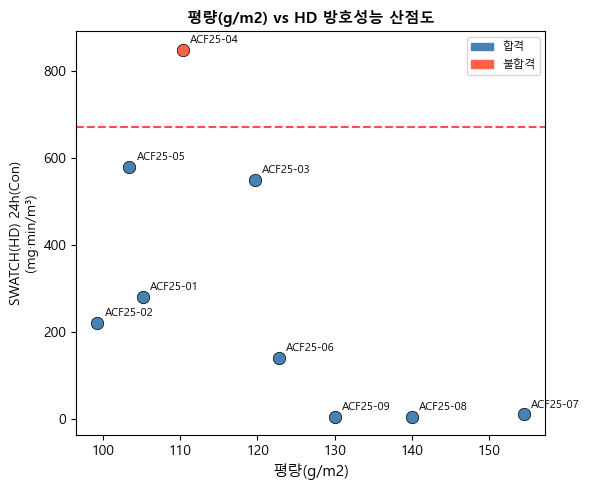

In [12]:
fig, ax = plt.subplots(figsize=(6,5))

x_col, y_col, y_label, color, lim = pairs[2]

x = df[x_col]
y = df[y_col]

slope, intercept, r, p, se = stats.linregress(x, y)

for _, row in df.iterrows():
    c = 'steelblue' if row[y_col] <= lim else 'tomato'
    ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
    ax.annotate(row['Sample'], (row[x_col], row[y_col]),
        textcoords='offset points', xytext=(5, 5), fontsize=8)

# 기준선
ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

# 레이블
ax.set_xlabel(x_col, fontsize=11)
ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
ax.set_title(f'{x_col} vs {y_label} 산점도', fontsize=11, fontweight='bold')

# 범례
pass_p = mpatches.Patch(color='steelblue', label='합격')
fail_p = mpatches.Patch(color='tomato', label='불합격')
ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

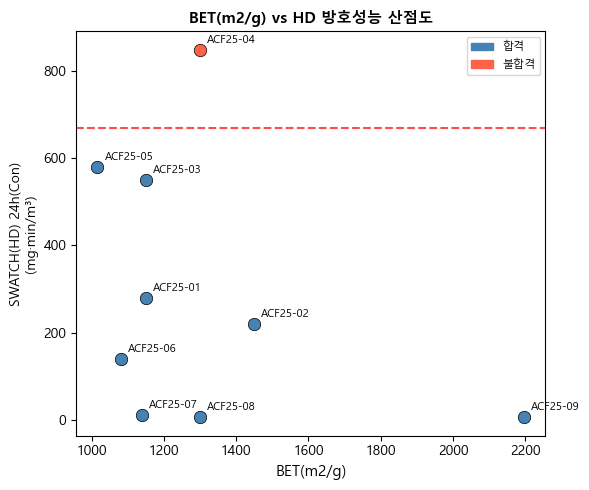

In [13]:
fig, ax = plt.subplots(figsize=(6,5))

x_col, y_col, y_label, color, lim = pairs[3]

x = df[x_col]
y = df[y_col]

slope, intercept, r, p, se = stats.linregress(x, y)

for _, row in df.iterrows():
    c = 'steelblue' if row[y_col] <= lim else 'tomato'
    ax.scatter(row[x_col], row[y_col], color=c, s=80, edgecolors='black', linewidths=0.5)
    ax.annotate(row['Sample'], (row[x_col], row[y_col]),
        textcoords='offset points', xytext=(5, 5), fontsize=8)

# 기준선
ax.axhline(lim, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'기준={lim}')

# 레이블
ax.set_xlabel(x_col, fontsize=11)
ax.set_ylabel(y_col + f'\n(mg·min/m³)', fontsize=10)
ax.set_title(f'{x_col} vs {y_label} 산점도', fontsize=11, fontweight='bold')

# 범례
pass_p = mpatches.Patch(color='steelblue', label='합격')
fail_p = mpatches.Patch(color='tomato', label='불합격')
ax.legend(handles=[pass_p, fail_p], fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

# 2D 합/불 시각화

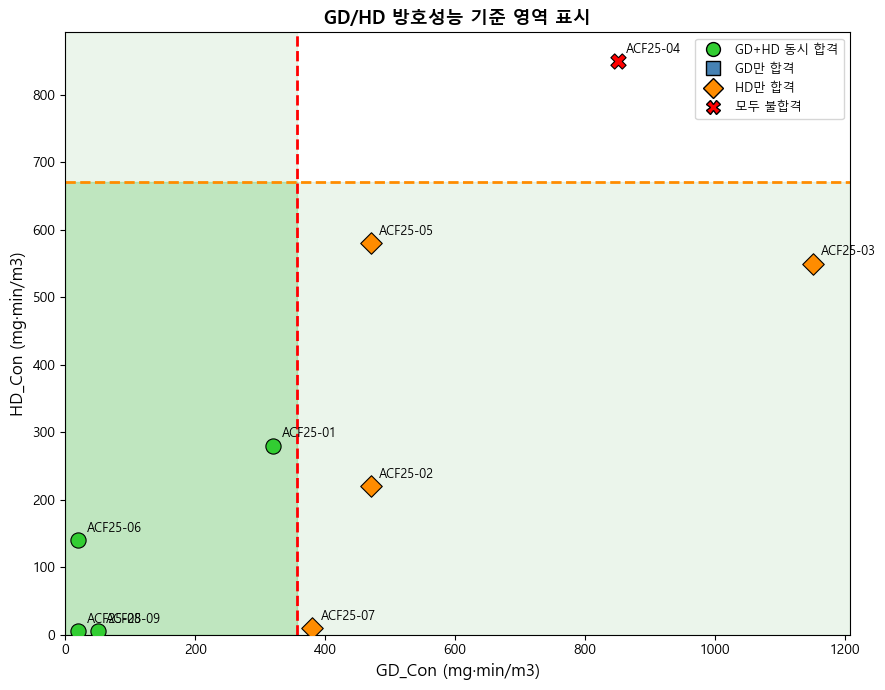

In [14]:
fig, ax = plt.subplots(figsize=(9,7))

# 합격
ax.axhspan(0, HD_base, xmin=0, alpha=0.08, color='green')
ax.axvspan(0, GD_base, alpha=0.08, color='green')
ax.fill_betweenx([0, HD_base], 0, GD_base, alpha=0.15, color='limegreen', label='GD+HD 동시 합격')

# 기준선
ax.axvline(GD_base, color='red', linestyle='--', linewidth=2, label=f'GD 기준 = {GD_base}')
ax.axhline(HD_base, color='darkorange', linestyle='--', linewidth=2, label=f'HD 기준 = {HD_base}')

# point
for _, row in df.iterrows():
    both = (row['SWATCH(GD) 24h(Con)'] <= GD_base) and (row['SWATCH(HD) 24h(Con)'] <= HD_base)
    gd_only = (row['SWATCH(GD) 24h(Con)'] <= GD_base) and (row['SWATCH(HD) 24h(Con)'] > HD_base)
    hd_only = (row['SWATCH(GD) 24h(Con)'] > GD_base) and (row['SWATCH(HD) 24h(Con)'] <= HD_base)
    
    if both:
        c, marker, label = 'limegreen', 'o', 'GD+HD 합격'
    elif gd_only:
        c, marker, label = 'steelblue', 's', 'GD만 합격'
    elif hd_only:
        c, marker, label = 'darkorange', 'D', 'HD만 합격'
    else:
        c, marker, label = 'red', 'X', 'GD+HD 불합격'

    ax.scatter(row['SWATCH(GD) 24h(Con)'], row['SWATCH(HD) 24h(Con)'], color=c, marker=marker,
               s=120, zorder=5, edgecolors='black', linewidths=0.8)
    ax.annotate(row['Sample'], (row['SWATCH(GD) 24h(Con)'], row['SWATCH(HD) 24h(Con)']),
                textcoords='offset points', xytext=(6, 6), fontsize=9)
    
    legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='limegreen',  markersize=10, label='GD+HD 동시 합격', markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='steelblue',  markersize=10, label='GD만 합격',       markeredgecolor='black'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='darkorange', markersize=10, label='HD만 합격',       markeredgecolor='black'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='red',        markersize=10, label='모두 불합격',     markeredgecolor='black'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')

ax.set_xlabel('GD_Con (mg·min/m3)', fontsize=12)
ax.set_ylabel('HD_Con (mg·min/m3)', fontsize=12)
ax.set_title('GD/HD 방호성능 기준 영역 표시', fontsize=13, fontweight='bold')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# 3D 시각화

In [15]:
pairs_3d = [
    ('평량(g/m2)', 'BET(m2/g)', 'SWATCH(GD) 24h(Con)', 'GD 방호성능', 'RdYlGn_r', GD_base),
    ('평량(g/m2)', 'BET(m2/g)', 'SWATCH(HD) 24h(Con)', 'HD 방호성능', 'RdYlGn_r', HD_base),
]

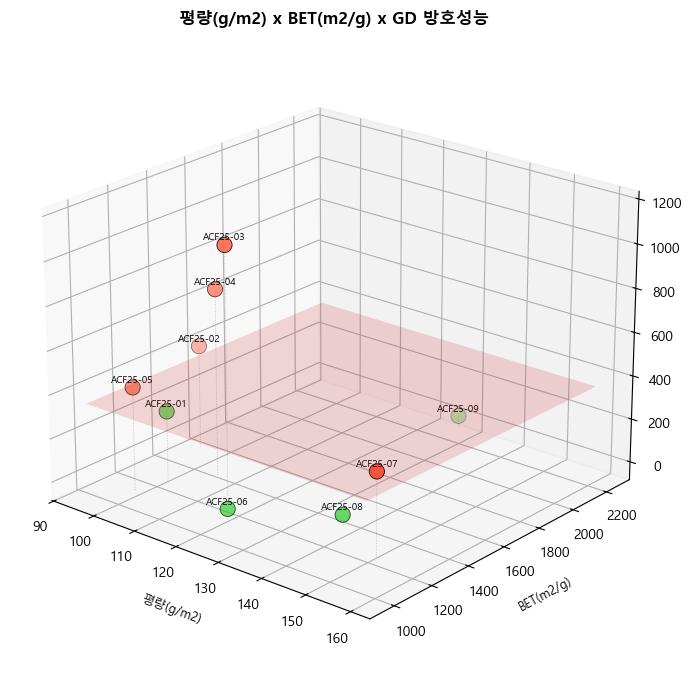

In [16]:
x1_col, x2_col, y_col, title, cmap, lim = pairs_3d[0]

fig, ax = plt.subplots(figsize=(16,7), subplot_kw={'projection': '3d'})

x1 = df[x1_col].values
x2 = df[x2_col].values
y = df[y_col].values

# 합/불 색상
colors = ['limegreen' if v <= lim else 'tomato' for v in y]
sizes = [120] * len(y)

# 3d 산점도
ax.scatter(x1, x2, y, c=colors, s=sizes,
           edgecolors='black', linewidths=0.6, depthshade=True)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min()-5, x1.max()+5, 10),
    np.linspace(x2.min()-50, x2.max()+50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

# 바닥 수직선
for xi, yi, zi in zip(x1, x2, y):
    ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 표시
for _, row in df.iterrows():
    ax.text(row[x1_col], row[x2_col], row[y_col] + 20,
            row['Sample'], fontsize=7, ha='center')

ax.set_xlabel(x1_col, fontsize=9, labelpad=8)
ax.set_ylabel(x2_col, fontsize=9, labelpad=8)
ax.set_title(f'{x1_col} x {x2_col} x {title}', fontsize=12, fontweight='bold')
ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.show()

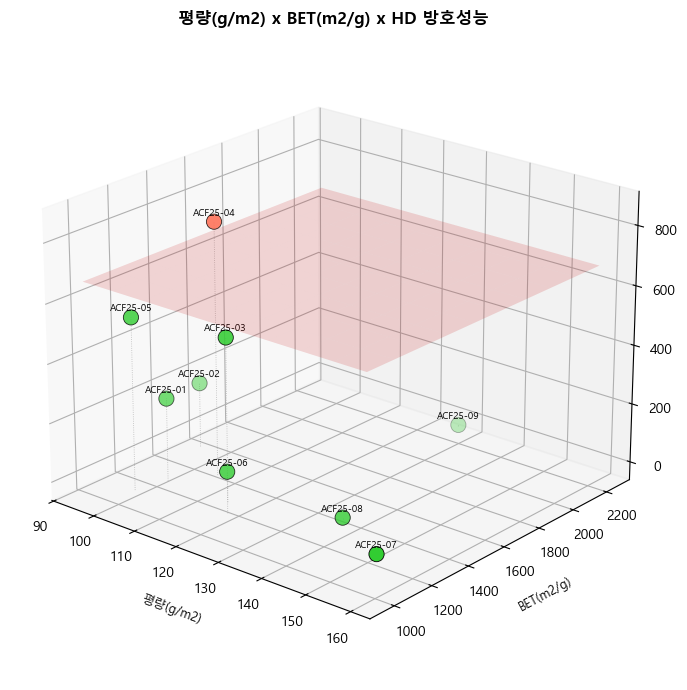

In [17]:
x1_col, x2_col, y_col, title, cmap, lim = pairs_3d[1]

fig, ax = plt.subplots(figsize=(16,7), subplot_kw={'projection': '3d'})

x1 = df[x1_col].values
x2 = df[x2_col].values
y = df[y_col].values

# 합/불 색상
colors = ['limegreen' if v <= lim else 'tomato' for v in y]
sizes = [120] * len(y)

# 3d 산점도
ax.scatter(x1, x2, y, c=colors, s=sizes,
           edgecolors='black', linewidths=0.6, depthshade=True)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min()-5, x1.max()+5, 10),
    np.linspace(x2.min()-50, x2.max()+50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

# 바닥 수직선
for xi, yi, zi in zip(x1, x2, y):
    ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 표시
for _, row in df.iterrows():
    ax.text(row[x1_col], row[x2_col], row[y_col] + 20,
            row['Sample'], fontsize=7, ha='center')

ax.set_xlabel(x1_col, fontsize=9, labelpad=8)
ax.set_ylabel(x2_col, fontsize=9, labelpad=8)
ax.set_title(f'{x1_col} x {x2_col} x {title}', fontsize=12, fontweight='bold')
ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.show()

# Multiple Linear Regression

In [18]:
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con),GD_PASS,HD_PASS,All_PASS
0,ACF25-01,105.20,1150,320,280,True,True,True
1,ACF25-02,99.30,1450,470,220,False,True,False
2,ACF25-03,119.70,1150,1150,550,False,True,False
3,ACF25-04,110.40,1300,850,850,False,False,False
4,ACF25-05,103.44,1016,470,580,False,True,False
5,ACF25-06,122.83,1080,20,140,True,True,True
6,ACF25-07,154.49,1139,380,10,False,True,False
7,ACF25-08,140.00,1300,20,5,True,True,True
8,ACF25-09,130.00,2197,50,5,True,True,True


In [19]:
samples = df['Sample'].tolist()

Q("SWATCH(GD) 24h(Con)") ~ Q("평량(g/m2)") + Q("BET(m2/g)")
pred_GD: [557.08464971 507.3918789  466.06436567 481.07858741 606.87140838
 466.65321462 250.85850562 295.27166274  98.72572695]
                               OLS Regression Results                               
Dep. Variable:     Q("SWATCH(GD) 24h(Con)")   R-squared:                       0.182
Model:                                  OLS   Adj. R-squared:                 -0.091
Method:                       Least Squares   F-statistic:                    0.6664
Date:                      Tue, 21 Apr 2026   Prob (F-statistic):              0.548
Time:                              11:54:47   Log-Likelihood:                -64.937
No. Observations:                         9   AIC:                             135.9
Df Residuals:                             6   BIC:                             136.5
Df Model:                                 2                                         
Covariance Type:                  nonrobust     

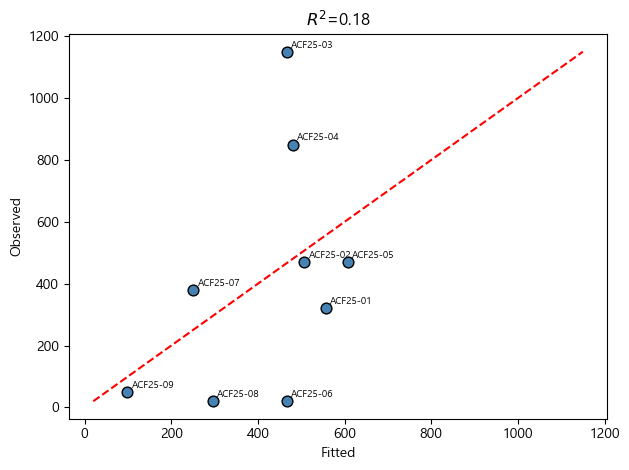

In [20]:
# GD방호성능 Regression
x1_col, x2_col, y_col, _, _, _ = pairs_3d[0]

formula = f'Q("{y_col}") ~ Q("{x1_col}") + Q("{x2_col}")'
print(formula)

model_GD = smf.ols(formula, data = df)

result_GD = model_GD.fit()
pred_GD = result_GD.predict()
print('pred_GD:', pred_GD)
print(result_GD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_GD = df[y_col]

ax.scatter(pred_GD, true_y_GD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_GD.min(), true_y_GD.max()], [true_y_GD.min(), true_y_GD.max()],
        linestyle='--', color='red')
for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
    ax.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_GD.rsquared:.2f}')

plt.tight_layout()
plt.show()

Q("SWATCH(HD) 24h(Con)") ~ Q("평량(g/m2)") + Q("BET(m2/g)")
pred_HD: [477.63195748 461.94377834 339.88740398 392.36592922 526.39335986
 326.89197104  12.02579046 111.17704758  -8.31723795]
                               OLS Regression Results                               
Dep. Variable:     Q("SWATCH(HD) 24h(Con)")   R-squared:                       0.454
Model:                                  OLS   Adj. R-squared:                  0.272
Method:                       Least Squares   F-statistic:                     2.496
Date:                      Tue, 21 Apr 2026   Prob (F-statistic):              0.163
Time:                              11:54:48   Log-Likelihood:                -60.934
No. Observations:                         9   AIC:                             127.9
Df Residuals:                             6   BIC:                             128.5
Df Model:                                 2                                         
Covariance Type:                  nonrobust     

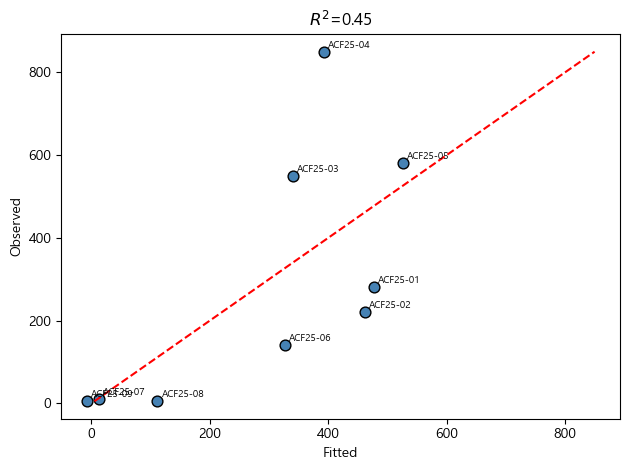

In [21]:
# HD방호성능 Regression
x1_col, x2_col, y_col, _, _, _ = pairs_3d[1]

formula = f'Q("{y_col}") ~ Q("{x1_col}") + Q("{x2_col}")'
print(formula)

model_HD = smf.ols(formula, data = df)

result_HD = model_HD.fit()
pred_HD = result_HD.predict()
print('pred_HD:', pred_HD)
print(result_HD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_HD = df[y_col]

ax.scatter(pred_HD, true_y_HD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_HD.min(), true_y_HD.max()], [true_y_HD.min(), true_y_HD.max()],
        linestyle='--', color='red')
for idx, (xi, yi) in enumerate(zip(pred_HD, true_y_HD)):
    ax.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_HD.rsquared:.2f}')

plt.tight_layout()
plt.show()

# 3D + 회귀평면

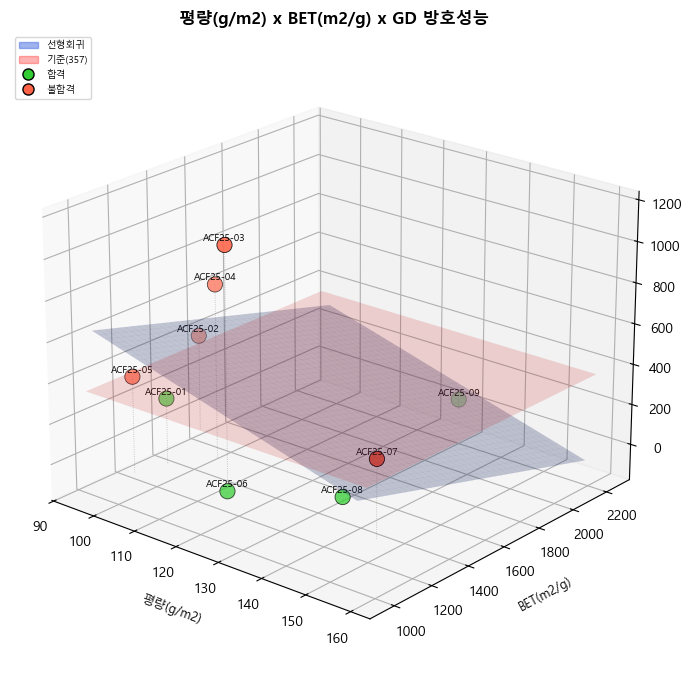

In [22]:
x1_col, x2_col, y_col, title, cmap, lim = pairs_3d[0]

fig, ax = plt.subplots(figsize=(16,7), subplot_kw={'projection': '3d'})

x1 = df[x1_col].values
x2 = df[x2_col].values
y = df[y_col].values

####################################
# 회귀 평면 생성
b0, b1, b2 = result_GD.params
r2 = result_GD.rsquared

x1_grid = np.linspace(x1.min() - 3,  x1.max() + 3,  40)
x2_grid = np.linspace(x2.min() - 50, x2.max() + 50, 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
Zg = b0 + b1 * X1g + b2 * X2g

# 회귀 평면 (파란색)
ax.plot_surface(X1g, X2g, Zg, alpha=0.25, color='royalblue', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg, alpha=0.08, color='navy', linewidth=0.3)
####################################


# 합/불 색상
colors = ['limegreen' if v <= lim else 'tomato' for v in y]
sizes = [120] * len(y)

# 3d 산점도
ax.scatter(x1, x2, y, c=colors, s=sizes,
           edgecolors='black', linewidths=0.6, depthshade=True)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min()-5, x1.max()+5, 10),
    np.linspace(x2.min()-50, x2.max()+50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

# 바닥 수직선
for xi, yi, zi in zip(x1, x2, y):
    ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 표시
for _, row in df.iterrows():
    ax.text(row[x1_col], row[x2_col], row[y_col] + 20,
            row['Sample'], fontsize=7, ha='center')

ax.set_xlabel(x1_col, fontsize=9, labelpad=8)
ax.set_ylabel(x2_col, fontsize=9, labelpad=8)
ax.set_title(f'{x1_col} x {x2_col} x {title}', fontsize=12, fontweight='bold')

leg = [
    mpatches.Patch(color='royalblue', alpha=0.5, label='선형회귀'),
    mpatches.Patch(color='red',       alpha=0.3, label=f'기준({lim})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
            markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
            markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')
ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.show()

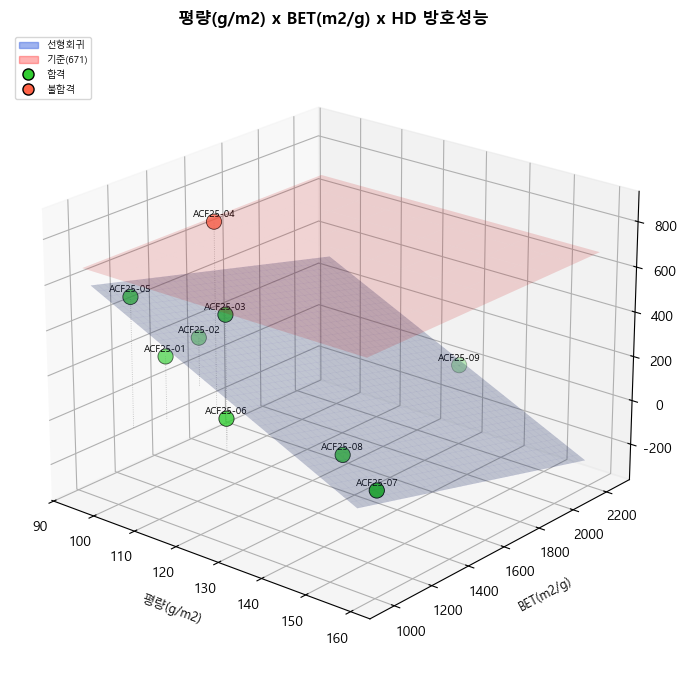

In [23]:
x1_col, x2_col, y_col, title, cmap, lim = pairs_3d[1]

fig, ax = plt.subplots(figsize=(16,7), subplot_kw={'projection': '3d'})

x1 = df[x1_col].values
x2 = df[x2_col].values
y = df[y_col].values

####################################
# 회귀 평면 생성
b0, b1, b2 = result_HD.params
r2 = result_HD.rsquared

x1_grid = np.linspace(x1.min() - 3,  x1.max() + 3,  40)
x2_grid = np.linspace(x2.min() - 50, x2.max() + 50, 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
Zg = b0 + b1 * X1g + b2 * X2g

# 회귀 평면 (파란색)
ax.plot_surface(X1g, X2g, Zg, alpha=0.25, color='royalblue', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg, alpha=0.08, color='navy', linewidth=0.3)
####################################


# 합/불 색상
colors = ['limegreen' if v <= lim else 'tomato' for v in y]
sizes = [120] * len(y)

# 3d 산점도
ax.scatter(x1, x2, y, c=colors, s=sizes,
           edgecolors='black', linewidths=0.6, depthshade=True)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min()-5, x1.max()+5, 10),
    np.linspace(x2.min()-50, x2.max()+50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

# 바닥 수직선
for xi, yi, zi in zip(x1, x2, y):
    ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 표시
for _, row in df.iterrows():
    ax.text(row[x1_col], row[x2_col], row[y_col] + 20,
            row['Sample'], fontsize=7, ha='center')

ax.set_xlabel(x1_col, fontsize=9, labelpad=8)
ax.set_ylabel(x2_col, fontsize=9, labelpad=8)
ax.set_title(f'{x1_col} x {x2_col} x {title}', fontsize=12, fontweight='bold')

leg = [
    mpatches.Patch(color='royalblue', alpha=0.5, label='선형회귀'),
    mpatches.Patch(color='red',       alpha=0.3, label=f'기준({lim})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
            markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
            markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')
ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.show()

# 3D + 스플라인 회귀면

Spline R^2 = 0.23373871390242384


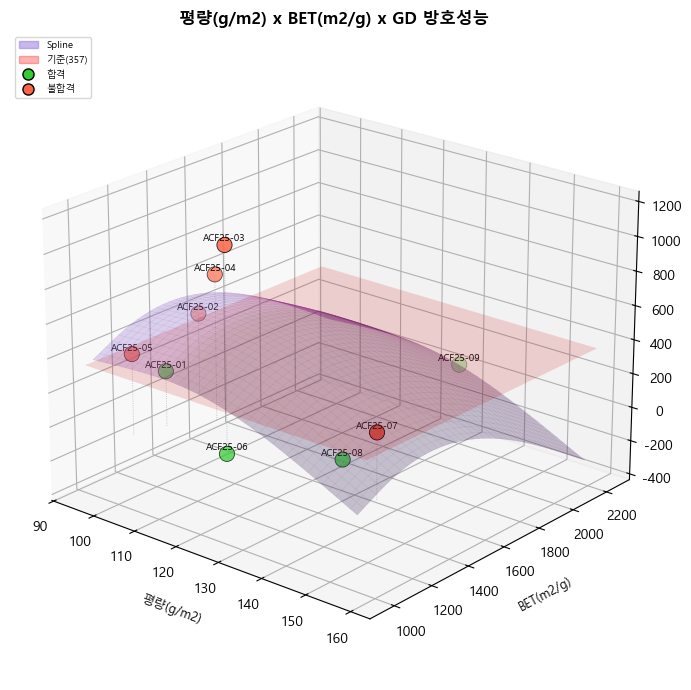

In [26]:
x1_col, x2_col, y_col, title, cmap, lim = pairs_3d[0]

fig, ax = plt.subplots(figsize=(16,7), subplot_kw={'projection': '3d'})

x1 = df[x1_col].values
x2 = df[x2_col].values
y = df[y_col].values

# 스플라인
k1 = float(np.median(x1))
k2 = float(np.median(x2))

formula = (
    f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
    f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})"
)

# 학습용 design matrix
train_dict = {'평량': x1, 'BET': x2}
X_spline = dmatrix(formula, train_dict, return_type='dataframe')

model_spline = sm.OLS(y, X_spline).fit()
print('Spline R^2 =', model_spline.rsquared)

# 스플라인 회귀면 예측
# grid 데이터를 넣어야 함
grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}

# 학습 때의 design_info를 이용해 grid 변환
Xg_spline = build_design_matrices([X_spline.design_info], grid_dict)[0]

pred_grid = model_spline.predict(Xg_spline)
Zg_spl = np.asarray(pred_grid).reshape(X1g.shape)

ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='mediumpurple', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='purple', linewidth=0.3)


#####################################
# 합/불 색상
colors = ['limegreen' if v <= lim else 'tomato' for v in y]
sizes = [120] * len(y)

# 3d 산점도
ax.scatter(x1, x2, y, c=colors, s=sizes,
           edgecolors='black', linewidths=0.6, depthshade=True)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min()-5, x1.max()+5, 10),
    np.linspace(x2.min()-50, x2.max()+50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

# 바닥 수직선
for xi, yi, zi in zip(x1, x2, y):
    ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 표시
for _, row in df.iterrows():
    ax.text(row[x1_col], row[x2_col], row[y_col] + 20,
            row['Sample'], fontsize=7, ha='center')

ax.set_xlabel(x1_col, fontsize=9, labelpad=8)
ax.set_ylabel(x2_col, fontsize=9, labelpad=8)
ax.set_title(f'{x1_col} x {x2_col} x {title}', fontsize=12, fontweight='bold')

leg = [
    mpatches.Patch(color='mediumpurple', alpha=0.5, label='Spline'),
    mpatches.Patch(color='red',       alpha=0.3, label=f'기준({lim})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
            markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
            markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')
ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.show()

Spline R^2 = 0.4996383804531854


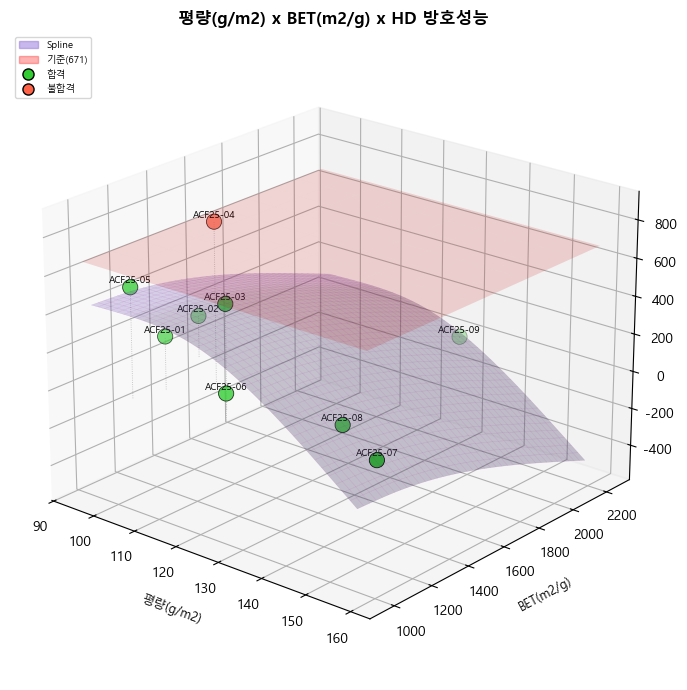

In [27]:
x1_col, x2_col, y_col, title, cmap, lim = pairs_3d[1]

fig, ax = plt.subplots(figsize=(16,7), subplot_kw={'projection': '3d'})

x1 = df[x1_col].values
x2 = df[x2_col].values
y = df[y_col].values

# 스플라인
k1 = float(np.median(x1))
k2 = float(np.median(x2))

formula = (
    f"cr(평량, knots=[{k1}], lower_bound={x1.min()}, upper_bound={x1.max()})"
    f" + cr(BET, knots=[{k2}], lower_bound={x2.min()}, upper_bound={x2.max()})"
)

# 학습용 design matrix
train_dict = {'평량': x1, 'BET': x2}
X_spline = dmatrix(formula, train_dict, return_type='dataframe')

model_spline = sm.OLS(y, X_spline).fit()
print('Spline R^2 =', model_spline.rsquared)

# 스플라인 회귀면 예측
# grid 데이터를 넣어야 함
grid_dict = {'평량': X1g.ravel(), 'BET': X2g.ravel()}

# 학습 때의 design_info를 이용해 grid 변환
Xg_spline = build_design_matrices([X_spline.design_info], grid_dict)[0]

pred_grid = model_spline.predict(Xg_spline)
Zg_spl = np.asarray(pred_grid).reshape(X1g.shape)

ax.plot_surface(X1g, X2g, Zg_spl, alpha=0.28, color='mediumpurple', edgecolor='none')
ax.plot_wireframe(X1g, X2g, Zg_spl, alpha=0.15, color='purple', linewidth=0.3)


#####################################
# 합/불 색상
colors = ['limegreen' if v <= lim else 'tomato' for v in y]
sizes = [120] * len(y)

# 3d 산점도
ax.scatter(x1, x2, y, c=colors, s=sizes,
           edgecolors='black', linewidths=0.6, depthshade=True)

# 기준 평면
xx, yy = np.meshgrid(
    np.linspace(x1.min()-5, x1.max()+5, 10),
    np.linspace(x2.min()-50, x2.max()+50, 10)
)
zz = np.full_like(xx, lim)
ax.plot_surface(xx, yy, zz, alpha=0.15, color='red')

# 바닥 수직선
for xi, yi, zi in zip(x1, x2, y):
    ax.plot([xi, xi], [yi, yi], [0, zi], color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# 샘플 표시
for _, row in df.iterrows():
    ax.text(row[x1_col], row[x2_col], row[y_col] + 20,
            row['Sample'], fontsize=7, ha='center')

ax.set_xlabel(x1_col, fontsize=9, labelpad=8)
ax.set_ylabel(x2_col, fontsize=9, labelpad=8)
ax.set_title(f'{x1_col} x {x2_col} x {title}', fontsize=12, fontweight='bold')

leg = [
    mpatches.Patch(color='mediumpurple', alpha=0.5, label='Spline'),
    mpatches.Patch(color='red',       alpha=0.3, label=f'기준({lim})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='limegreen',
            markersize=8, label='합격', markeredgecolor='black'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
            markersize=8, label='불합격', markeredgecolor='black'),
]
ax.legend(handles=leg, fontsize=7, loc='upper left')
ax.view_init(elev=22, azim=-50)

plt.tight_layout()
plt.show()

# 회귀모형 진단

In [28]:
samples = df['Sample'].tolist()

# Residual vs. Fitted

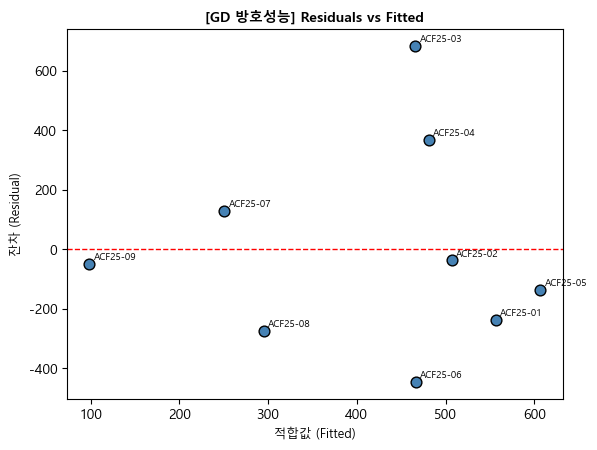

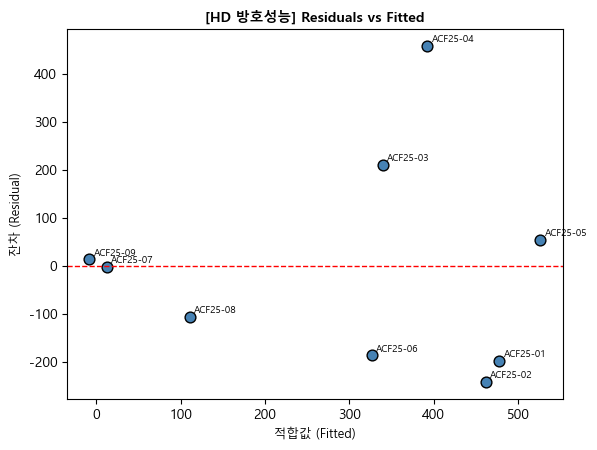

In [29]:
residuals_GD = result_GD.resid
fitted_GD = result_GD.fittedvalues

plt.scatter(fitted_GD, residuals_GD, color='steelblue', edgecolors='black', s=60)
plt.axhline(0, color='red', linestyle='--', linewidth=1)

for idx, (xi, yi) in enumerate(zip(fitted_GD, residuals_GD)):
    plt.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
plt.xlabel('적합값 (Fitted)', fontsize=9)
plt.ylabel('잔차 (Residual)', fontsize=9)
plt.title(f'[GD 방호성능] Residuals vs Fitted', fontsize=10, fontweight='bold')
plt.show()


residuals_HD = result_HD.resid
fitted_HD = result_HD.fittedvalues

plt.scatter(fitted_HD, residuals_HD, color='steelblue', edgecolors='black', s=60)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
for idx, (xi, yi) in enumerate(zip(fitted_HD, residuals_HD)):
    plt.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
plt.xlabel('적합값 (Fitted)', fontsize=9)
plt.ylabel('잔차 (Residual)', fontsize=9)
plt.title(f'[HD 방호성능] Residuals vs Fitted', fontsize=10, fontweight='bold')
plt.show()

# Normal Q-Q Plot

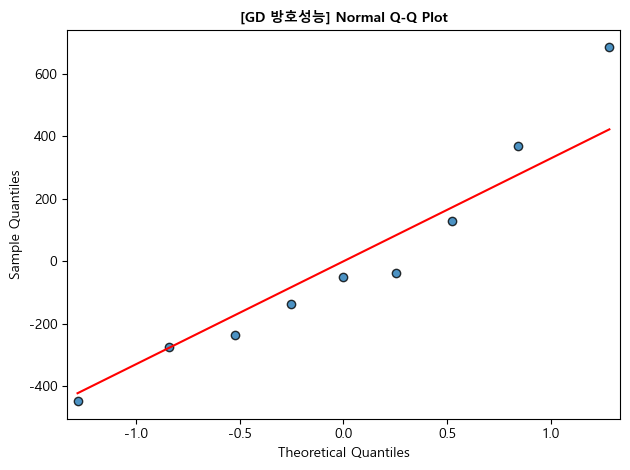

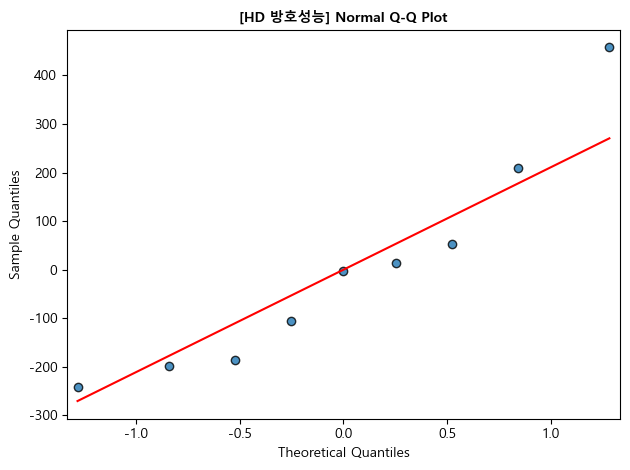

In [31]:
# GD 방호성능
fig, ax = plt.subplots()

pp = ProbPlot(residuals_GD)
pp.qqplot(line='s', ax=ax, alpha=0.8)

for line in ax.get_lines():
    if line.get_linestyle() == 'None':  # 데이터 점
        line.set_color('steelblue')
        line.set_markersize(6)
        line.set_markeredgecolor('black')
for idx, (xi, yi) in enumerate(zip(true_y_GD, pred_GD)):
    plt.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3,3), textcoords='offset points')

ax.set_title('[GD 방호성능] Normal Q-Q Plot', fontsize=10, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

# HD 방호성능
fig, ax = plt.subplots()

pp = ProbPlot(residuals_HD)
pp.qqplot(line='s', ax=ax, alpha=0.8)

for line in ax.get_lines():
    if line.get_linestyle() == 'None':  # 데이터 점
        line.set_color('steelblue')
        line.set_markersize(6)
        line.set_markeredgecolor('black')
for idx, (xi, yi) in enumerate(zip(true_y_HD, pred_HD)):
    plt.annotate(samples[idx], (xi, yi),
                fontsize=7, xytext=(3,3), textcoords='offset points')

# 제목 및 라벨
ax.set_title('[HD 방호성능] Normal Q-Q Plot', fontsize=10, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

# Cook's Distance

In [34]:
n = df.shape[0]
threshold = 4 / n
samples = df['Sample'].tolist()

Cook's distance: [0.03974216 0.00193061 0.17452835 0.05785281 0.0210664  0.09888298
 0.12712191 0.0706434  0.32202719]
leverage: [0.21324923 0.31536986 0.135784   0.14973769 0.28226665 0.16741827
 0.59855684 0.25329102 0.88432643]


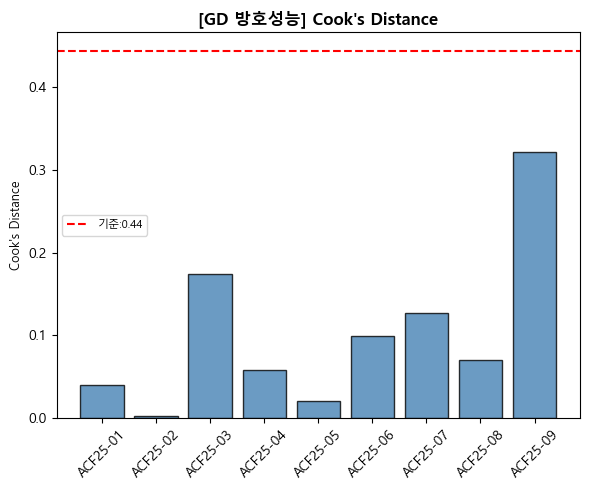

Cook's distance: [6.72097435e-02 1.96716977e-01 4.00878680e-02 2.16654006e-01
 7.86457487e-03 4.21342403e-02 7.61291691e-05 2.55789732e-02
 5.85433344e-02]
leverage: [0.21324923 0.31536986 0.135784   0.14973769 0.28226665 0.16741827
 0.59855684 0.25329102 0.88432643]


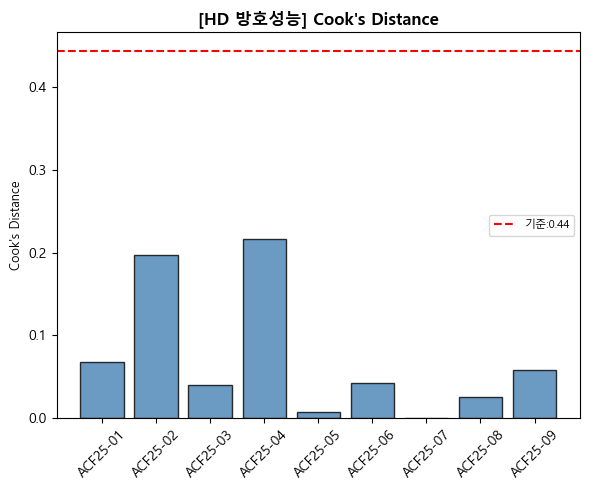

In [35]:
# GD 방호성능
cooks_distance_GD = result_GD.get_influence().cooks_distance[0]

bar_colors = ['tomato' if c > threshold else 'steelblue' for c in cooks_distance_GD]

influence_GD = result_GD.get_influence()

# Cook's distance
print("Cook's distance:", influence_GD.cooks_distance[0])

# leverage
print('leverage:', influence_GD.hat_matrix_diag)

fig, axes = plt.subplots(1, 1, figsize=(6,5))
axes.bar(samples, cooks_distance_GD, color=bar_colors, edgecolor='black', alpha=0.8)
axes.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
               label=f'기준:{threshold:.2f}')
axes.set_title("[GD 방호성능] Cook's Distance", fontweight='bold')
axes.set_ylabel("Cook's Distance", fontsize=9)
axes.tick_params(axis='x', rotation=45)
axes.legend(fontsize=8)

plt.tight_layout()
plt.show()

# HD 방호성능
cooks_distance_HD = result_HD.get_influence().cooks_distance[0]

bar_colors = ['tomato' if c > threshold else 'steelblue' for c in cooks_distance_HD]

influence_HD = result_HD.get_influence()

# Cook's distance
print("Cook's distance:", influence_HD.cooks_distance[0])

# leverage
print('leverage:', influence_HD.hat_matrix_diag)

fig, axes = plt.subplots(1, 1, figsize=(6,5))
axes.bar(samples, cooks_distance_HD, color=bar_colors, edgecolor='black', alpha=0.8)
axes.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
               label=f'기준:{threshold:.2f}')
axes.set_title("[HD 방호성능] Cook's Distance", fontweight='bold')
axes.set_ylabel("Cook's Distance", fontsize=9)
axes.tick_params(axis='x', rotation=45)
axes.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 다중공선성

In [38]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [39]:
bp_test_GD = het_breuschpagan(result_GD.resid, result_GD.model.exog)
print(bp_test_GD)

bp_test_HD = het_breuschpagan(result_HD.resid, result_HD.model.exog)
print(bp_test_HD)

(0.9114672199531962, 0.6339827012723132, 0.3380590441080917, 0.72590823178196)
(1.3902919586274765, 0.4990015987570844, 0.5480993295940103, 0.604472371926351)


In [40]:
X = result_GD.model.exog

for i in range(X.shape[1]):
    print(i, variance_inflation_factor(X, i))

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif

0 58.50296950588993
1 1.015962824398935
2 1.015962824398935


,VIF Factor
0,58.502970
1,1.015963
2,1.015963


In [41]:
X = result_HD.model.exog

for i in range(X.shape[1]):
    print(i, variance_inflation_factor(X, i))

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif

0 58.50296950588993
1 1.015962824398935
2 1.015962824398935


,VIF Factor
0,58.502970
1,1.015963
2,1.015963
